# Crypto Trader Behavior vs Market Sentiment Analysis

## Objective
Analyze whether trader profitability and behavior change under different Fear & Greed market conditions using historical crypto trade data and sentiment index data.

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Import Libraries
Libraries used for data manipulation, visualization, and statistical analysis.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Load Datasets

Two datasets were used:

1. Fear & Greed Index dataset containing daily market sentiment.
2. Historical trade dataset containing executed crypto trades.

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

In [5]:
fear_greed = pd.read_csv("data/fear_greed_index.csv")

In [6]:
trades = pd.read_csv(
    "data/historical_data.csv"
)

## 3. Initial Data Inspection

We inspect both datasets to understand columns, formats, and sample records.

In [7]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Initial Observation

- Fear & Greed data is daily sentiment-based.
- Trade data contains transaction-level records.
- Date alignment will be required before merging.

## 4 Data Quality Assessment

We check for:

- Missing values
- Duplicate rows
- Incorrect datatypes
- Dataset dimensions

In [9]:
fear_greed.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [10]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [11]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [12]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
fear_greed.duplicated().sum()

np.int64(0)

In [14]:
trades.duplicated().sum()

np.int64(0)

### Data Quality Findings

- No major missing values in source datasets.
- No duplicate records found.
- Trade dataset contains over 211K rows, suitable for meaningful analysis.

## 5. Data Preparation & Merge

Both datasets were standardized to common date format and merged using trade date.

In [15]:
fear_greed["date"] = pd.to_datetime(fear_greed["date"]).dt.date

In [16]:
trades["date"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M",
).dt.date

In [17]:
merged_dataframe = trades.merge(
    fear_greed[["date", "value", "classification"]],
    on="date",
    how="left"
)

In [18]:
merged_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
 16  date              211224 non-nu

In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 1400)
pd.set_option("display.float_format", "{:.2f}".format)

In [20]:
merged_dataframe[[
    "Account",
    "Coin",
    "Side",
    "Size USD",
    "Closed PnL",
    "Timestamp IST",
    "date",
    "value",
    "classification"
]].head(10)

,Account,Coin,Side,Size USD,Closed PnL,Timestamp IST,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,11.27,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1151.77,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,272.00,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,368.00,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,100.00,0.00,02-12-2024 22:50,2024-12-02,80.00,Extreme Greed


In [22]:
merged_dataframe.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
value               6
classification      6
dtype: int64

In [23]:
merged_dataframe.duplicated().sum()

np.int64(0)

### Merge Result

- Successfully merged sentiment data with trade records.
- Final dataset contains sentiment labels for nearly all trade rows.
- Only a few unmatched records were found.

## 6. Market Sentiment Distribution

We examine how many trades occurred during each sentiment regime.

In [24]:
merged_dataframe["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [28]:
pnl_dataframe = merged_dataframe[merged_dataframe["Closed PnL"] != 0].copy()

In [30]:
pnl_dataframe.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
44,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,2446.39,22156.95,SELL,03-12-2024 14:39,10000.50,Sell,3008.23,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,7.75,519000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed
45,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,25.00,226.43,SELL,03-12-2024 14:39,7554.11,Sell,30.74,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.08,335000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed
46,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,33.40,302.20,SELL,03-12-2024 14:39,7529.11,Sell,40.77,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.11,514000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed
47,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,200.00,1809.28,SELL,03-12-2024 14:39,7495.71,Sell,243.81,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.63,954000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed
48,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.04,209.26,1892.21,SELL,03-12-2024 14:39,7295.71,Sell,254.26,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.66,747000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed


### Insight

- Fear periods had the highest number of trades.
- Extreme Fear had the lowest trade participation.
- Traders appear more active in moderately fearful conditions than panic extremes.

## 7. Profitability Analysis

We isolate closed trades and compare realized PnL across sentiment regimes.

In [31]:
pnl_dataframe.groupby("classification")["Closed PnL"].agg(
    ["count", "sum", "mean", "median"]
).sort_values(by="sum", ascending=False)

,count,sum,mean,median
classification,,,,
Fear,29808,3357155.44,112.63,6.35
Extreme Greed,20853,2715171.31,130.21,8.53
Greed,25176,2150129.27,85.40,4.93
Neutral,18159,1292920.68,71.20,4.58
Extreme Fear,10406,739110.25,71.03,6.39


### Key Findings

- Fear generated the highest total realized profit.
- Extreme Greed produced the highest average profit per trade.
- Neutral sentiment had the weakest performance.

## 8. Win Rate by Sentiment

Winning trades are defined as trades with positive closed PnL.

In [32]:
pnl_dataframe["win"] = pnl_dataframe["Closed PnL"] > 0

In [33]:
pnl_dataframe.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,win
44,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,2446.39,22156.95,SELL,03-12-2024 14:39,10000.50,Sell,3008.23,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,7.75,519000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True
45,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,25.00,226.43,SELL,03-12-2024 14:39,7554.11,Sell,30.74,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.08,335000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True
46,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,33.40,302.20,SELL,03-12-2024 14:39,7529.11,Sell,40.77,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.11,514000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True
47,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,200.00,1809.28,SELL,03-12-2024 14:39,7495.71,Sell,243.81,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.63,954000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True
48,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.04,209.26,1892.21,SELL,03-12-2024 14:39,7295.71,Sell,254.26,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.66,747000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True


In [34]:
pnl_dataframe.groupby("classification")["win"].mean() * 100

classification
Extreme Fear    76.22
Extreme Greed   89.17
Fear            87.29
Greed           76.89
Neutral         82.39
Name: win, dtype: float64

### Insight

- Extreme Greed recorded the highest win rate (~89%).
- Fear also showed strong win probability (~87%).
- Greed sentiment underperformed relative to Extreme Greed.

## 9. Loss Rate by Sentiment

In [35]:
pnl_dataframe["loss"] = pnl_dataframe["Closed PnL"] < 0

In [36]:
pnl_dataframe.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,win,loss
44,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,2446.39,22156.95,SELL,03-12-2024 14:39,10000.50,Sell,3008.23,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,7.75,519000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True,False
45,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.06,25.00,226.43,SELL,03-12-2024 14:39,7554.11,Sell,30.74,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.08,335000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True,False
46,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,33.40,302.20,SELL,03-12-2024 14:39,7529.11,Sell,40.77,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.11,514000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True,False
47,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.05,200.00,1809.28,SELL,03-12-2024 14:39,7495.71,Sell,243.81,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.63,954000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True,False
48,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.04,209.26,1892.21,SELL,03-12-2024 14:39,7295.71,Sell,254.26,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.66,747000000000000.00,1730000000000.00,2024-12-03,76.00,Extreme Greed,True,False


In [37]:
pnl_dataframe.groupby("classification")["loss"].mean() * 100

classification
Extreme Fear    23.78
Extreme Greed   10.83
Fear            12.71
Greed           23.11
Neutral         17.61
Name: loss, dtype: float64

### Insight

- Extreme Fear had the highest loss frequency.
- Greed sentiment also showed elevated losing trades.
- Fear periods still remained profitable overall despite volatility.

## 10. PnL Distribution & Volatility

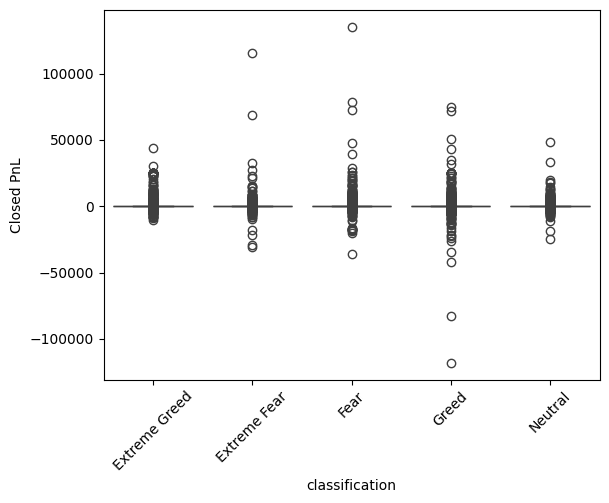

In [38]:
sns.boxplot(data=pnl_dataframe, x="classification", y="Closed PnL")
plt.xticks(rotation=45)
plt.show()

### Insight

- All sentiment groups contain significant outliers.
- Greed and Fear periods show wider dispersion in outcomes.
- Large winners and losers cluster during emotionally charged markets.

## 11. Position Sizing Behavior

In [39]:
avg_size = merged_dataframe.groupby("classification")["Size USD"].mean().reset_index()
avg_size.head()

,classification,Size USD
0,Extreme Fear,5349.73
1,Extreme Greed,3112.25
2,Fear,7816.11
3,Greed,5736.88
4,Neutral,4782.73


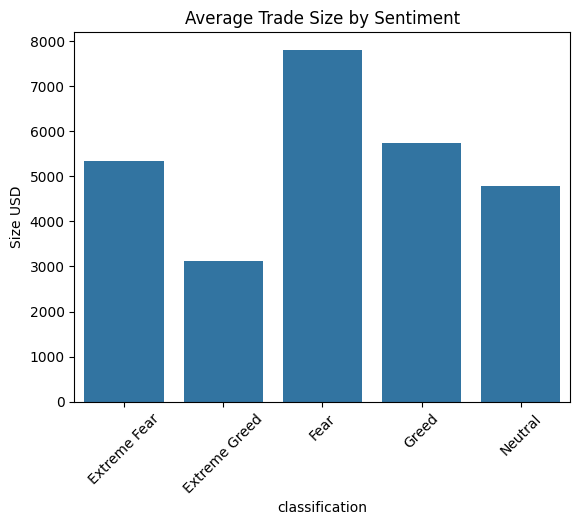

In [40]:
sns.barplot(data=avg_size, x="classification", y="Size USD")
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()

### Insight

- Largest average trade sizes occurred during Fear sentiment.
- Traders appear more aggressive during market declines.
- Extreme Greed showed the smallest average sizing.

## 12. Trading Activity Frequency

In [41]:
daily = merged_dataframe.groupby(["date","classification"]).size().reset_index(name="trade_count")
daily.head(20)

,date,classification,trade_count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3
5,2023-12-17,Greed,14
6,2023-12-18,Greed,2
7,2023-12-19,Greed,15
8,2023-12-20,Greed,18
9,2023-12-21,Greed,49


### Insight

- Trade counts increase noticeably during stronger sentiment phases.
- Emotional market environments attract more participation.

In [43]:
daily_pnl_per_account = (
    merged_dataframe.groupby(["date", "Account"])["Closed PnL"]
        .sum()
        .reset_index()
        .sort_values(["date", "Closed PnL"], ascending=[True,False])
)
daily_pnl_per_account.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.00
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.43
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.63
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00


## 13. Directional Bias (Long vs Short)

In [109]:
opens = merged_dataframe[merged_dataframe["Direction"].isin(["Open Long", "Open Short"])]

open_counts = opens["Direction"].value_counts()

longs = open_counts["Open Long"]
shorts = open_counts["Open Short"]

ratio = longs / shorts

In [110]:
sentiment_long_short_ratio = (
    merged_dataframe[merged_dataframe["Direction"].isin(["Open Long", "Open Short"])]
    .groupby(["classification", "Direction"])
    .size()
    .unstack(fill_value=0)
)

sentiment_long_short_ratio["Long_Short_Ratio"] = (
    sentiment_long_short_ratio["Open Long"] / sentiment_long_short_ratio["Open Short"]
)

sentiment_long_short_ratio

Direction,Open Long,Open Short,Long_Short_Ratio
classification,,,
Extreme Fear,7005,3174,2.21
Extreme Greed,6300,7663,0.82
Fear,17824,10887,1.64
Greed,8544,11664,0.73
Neutral,10222,6353,1.61


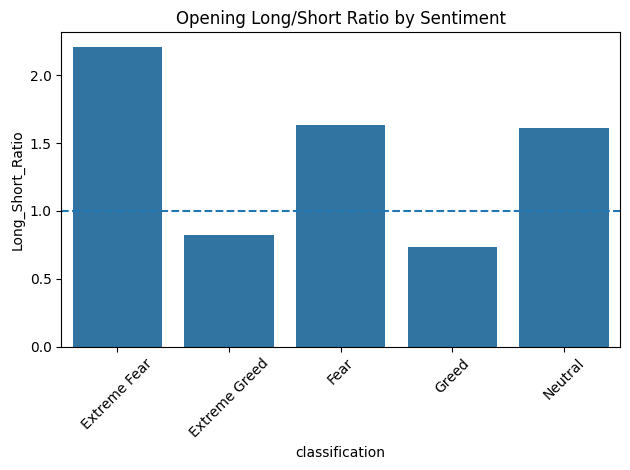

In [57]:
plot_df = sentiment_long_short_ratio.reset_index()

sns.barplot(
    data=plot_df,
    x="classification",
    y="Long_Short_Ratio"
)

plt.axhline(1, linestyle="--")
plt.title("Opening Long/Short Ratio by Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

- Extreme Fear had strongest long bias (2.21 long/short ratio).
- Fear also favored long exposure.
- Greed and Extreme Greed showed short bias (<1), indicating contrarian positioning.

## 14. Leverage Usage Analysis

In [112]:
merged_dataframe["leverage"] = merged_dataframe["leverage"].replace([np.inf, -np.inf], np.nan)

In [113]:
cleaned_leverage = merged_dataframe[merged_dataframe["leverage"] > 0].copy()

In [114]:
cleaned_leverage = cleaned_leverage[cleaned_leverage["leverage"] <= 100]

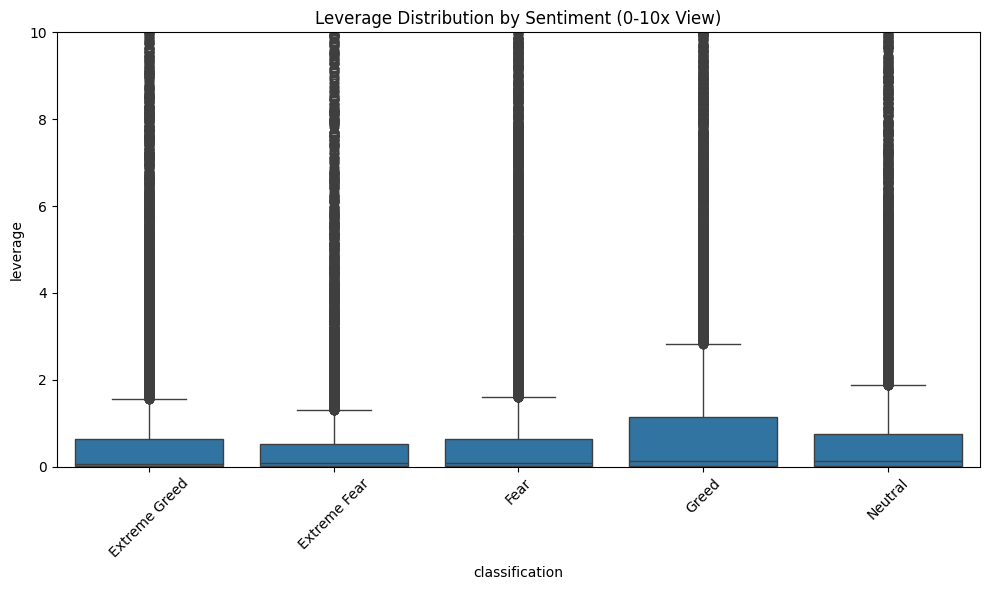

In [116]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=cleaned_leverage,
    x="classification",
    y="leverage"
)

plt.ylim(0,10)
plt.xticks(rotation=45)
plt.title("Leverage Distribution by Sentiment (0-10x View)")
plt.tight_layout()
plt.show()

In [77]:
cleaned_leverage.groupby("classification")["leverage"].agg(
    ["mean","median","max","count"]
)

,mean,median,max,count
classification,,,,
Extreme Fear,2.14,0.08,99.53,13591
Extreme Greed,2.97,0.06,99.88,22737
Fear,3.27,0.08,99.87,35919
Greed,4.48,0.14,99.97,21184
Neutral,2.83,0.12,99.92,21467


### Insight

- Median leverage remained relatively low overall.
- A minority of trades used extremely high leverage.
- High leverage behavior likely concentrated during volatile sentiment periods.

# Final Conclusions

## Key Insights

1. Fear sentiment produced the highest total profitability and largest average trade sizes.

2. Extreme Greed had the highest win rate, suggesting momentum continuation environments.

3. Traders become more directional during emotional markets:
   - Long bias in Fear
   - Short bias in Greed

4. High volatility sentiment periods generate both the best and worst trade outcomes.

## 1. Performance Comparison — Fear vs Greed Days
We compare whether traders perform differently during Fear vs Greed market sentiment using:

- Average Closed PnL
- Median Closed PnL
- Win Rate
- Loss Rate
- Trade Count

This helps determine whether trader profitability changes with market sentiment.

In [78]:
comparison_dataframe = merged_dataframe[
    merged_dataframe["classification"].isin(
        ["Fear", "Extreme Fear", "Greed", "Extreme Greed"]
    )
].copy()

comparison_dataframe["sentiment_group"] = comparison_dataframe["classification"].replace({
    "Fear": "Fear",
    "Extreme Fear": "Fear",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})

comparison_dataframe.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,leverage,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,80.00,Extreme Greed,NaN,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,80.00,Extreme Greed,0.13,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,80.00,Extreme Greed,1.15,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,80.00,Extreme Greed,1.00,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,80.00,Extreme Greed,0.05,Greed


In [79]:
performance = comparison_dataframe[comparison_dataframe["Closed PnL"] != 0].groupby("sentiment_group")["Closed PnL"].agg(
    trades="count",
    total_pnl="sum",
    avg_pnl="mean",
    median_pnl="median"
).round(2)

performance

,trades,total_pnl,avg_pnl,median_pnl
sentiment_group,,,,
Fear,40214,4096265.69,101.86,6.36
Greed,46029,4865300.58,105.70,6.49


In [80]:
comparison_pnl = comparison_dataframe[comparison_dataframe["Closed PnL"] != 0].copy()

comparison_pnl["win"] = comparison_pnl["Closed PnL"] > 0

winrate = comparison_pnl.groupby("sentiment_group")["win"].mean().mul(100).round(2)

winrate

sentiment_group
Fear    84.42
Greed   82.45
Name: win, dtype: float64

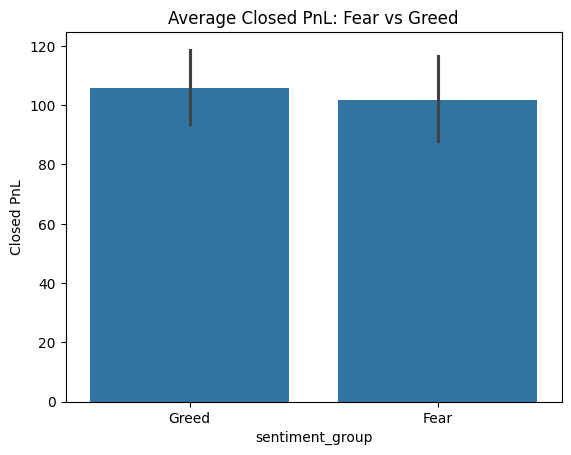

In [81]:
sns.barplot(
    data=comparison_pnl,
    x="sentiment_group",
    y="Closed PnL",
    estimator="mean"
)

plt.title("Average Closed PnL: Fear vs Greed")
plt.show()

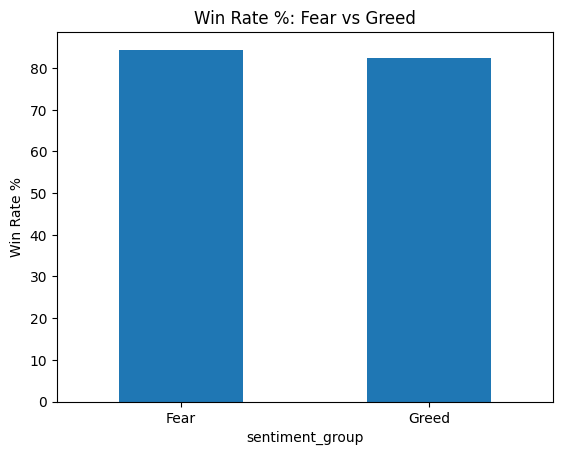

In [82]:
winrate.plot(kind="bar")
plt.title("Win Rate %: Fear vs Greed")
plt.ylabel("Win Rate %")
plt.xticks(rotation=0)
plt.show()

### Key Findings — Fear vs Greed Performance

1. Traders were slightly more profitable during **Greed** sentiment periods.

- Average Closed PnL on Greed days = **105.70**
- Average Closed PnL on Fear days = **101.86**

This suggests bullish market environments may offer slightly better profit opportunities.

---

2. Win rates were stronger during **Fear** periods.

- Fear win rate = **84.42%**
- Greed win rate = **82.45%**

Although profits were larger during Greed, traders were more consistently profitable during Fear markets.

---

3. Trade activity was higher during Greed sentiment.

- Greed trades = **46,029**
- Fear trades = **40,214**

This may indicate traders become more active when markets are optimistic.

---

4. Median PnL remained nearly identical across both environments.

- Fear median = **6.36**
- Greed median = **6.49**

This implies most trades perform similarly, while average differences are likely driven by larger winning trades.

## 2. Trader Behavior Under Fear vs Greed

We analyze whether traders adjust risk-taking and positioning behavior depending on market sentiment.

In [83]:
size_compare = comparison_dataframe.groupby("sentiment_group")["Size USD"].mean().round(2)
size_compare

sentiment_group
Fear    7182.01
Greed   4574.42
Name: Size USD, dtype: float64

In [88]:
lev_compare = comparison_dataframe.groupby("sentiment_group")["leverage"].median()
lev_compare

sentiment_group
Fear    0.02
Greed   0.00
Name: leverage, dtype: float64

In [85]:
bias = comparison_dataframe[
    comparison_dataframe["Direction"].isin(["Open Long","Open Short"])
]

bias_table = (
    bias.groupby("sentiment_group")["Direction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

bias_table

sentiment_group  Direction 
Fear             Open Long    63.84
                 Open Short   36.16
Greed            Open Short   56.56
                 Open Long    43.44
Name: proportion, dtype: float64

In [86]:
freq = comparison_dataframe["sentiment_group"].value_counts()
freq

sentiment_group
Greed    90295
Fear     83237
Name: count, dtype: int64

### Key Findings — Trader Behavior Under Fear vs Greed

1. Traders deploy larger position sizes during Fear markets.

- Fear average trade size = **$7,182**

- Greed average trade size = **$4,574**

This suggests traders become more aggressive when markets decline, potentially buying dips or averaging into positions.

---

2. Positioning direction changes sharply with sentiment.

During Fear markets:

- **63.84% Open Long**
- **36.16% Open Short**

During Greed markets:

- **56.56% Open Short**
- **43.44% Open Long**

This indicates traders often take contrarian positions:
buying during fear and shorting during greed.

---

3. Trade activity increases during Greed periods.

- Greed trades = **90,295**
- Fear trades = **83,237**

This suggests optimistic markets encourage more participation and faster trading activity.

---

4. Sentiment appears to influence risk behavior.

Traders increase size during Fear periods and trade more frequently during Greed periods, indicating different strategic responses depending on market mood.

5. Median leverage was higher during Fear sentiment.

- Fear median leverage = **0.02**
- Greed median leverage = **0.00**

Although leverage values are highly skewed, median values suggest traders used slightly more leverage during Fear markets.

# 3. Trader Segmentation Analysis

To understand whether different trader types behave differently, traders were segmented into groups based on:

- Trading Frequency (number of trades)
- Total Profitability (Closed PnL)
- Win Rate Consistency

This helps identify which trader profiles generate better outcomes.

In [96]:
trader_freq = merged_dataframe.groupby("Account").size().reset_index(name="trade_count")

trader_freq["segment"] = pd.qcut(
    trader_freq["trade_count"],
    q=3,
    labels=["Low Frequency","Medium Frequency","High Frequency"]
)
trader_freq

,Account,trade_count,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Medium Frequency
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Frequency
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Medium Frequency
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Frequency
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Medium Frequency
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,Low Frequency
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,Medium Frequency
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,Low Frequency
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,Low Frequency
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,Low Frequency


In [97]:
trader_pnl = merged_dataframe.groupby("Account")["Closed PnL"].sum().reset_index()

trader_pnl["segment"] = pd.qcut(
    trader_pnl["Closed PnL"],
    q=3,
    labels=["Low PnL","Mid PnL","High PnL"]
)
trader_pnl

,Account,Closed PnL,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,High PnL
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,Low PnL
2,0x271b280974205ca63b716753467d5a371de622ab,-70436.19,Low PnL
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132464.81,Mid PnL
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,Mid PnL
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.60,Low PnL
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.92,Low PnL
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,53496.25,Low PnL
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,199505.59,Mid PnL
9,0x430f09841d65beb3f27765503d0f850b8bce7713,416541.87,High PnL


In [98]:
wins = comparison_pnl.groupby("Account")["win"].mean().mul(100).reset_index()

wins["segment"] = pd.qcut(
    wins["win"],
    q=3,
    labels=["Low Win Rate","Medium Win Rate","High Win Rate"]
)
wins

,Account,win,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,75.86,Low Win Rate
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,78.55,Low Win Rate
2,0x271b280974205ca63b716753467d5a371de622ab,83.82,Medium Win Rate
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,85.69,Medium Win Rate
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,79.59,Medium Win Rate
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,65.12,Low Win Rate
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,64.27,Low Win Rate
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,100.00,High Win Rate
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,100.00,High Win Rate
9,0x430f09841d65beb3f27765503d0f850b8bce7713,100.00,High Win Rate


## 3.1 Frequency Segments

Traders were divided into:

- Low Frequency
- Medium Frequency
- High Frequency

Examples from the dataset show:

- Low frequency traders executed a few hundred to ~1,500 trades
- Medium frequency traders executed ~2,000 to ~5,000 trades
- High frequency traders executed 7,000+ trades, with some above 40,000 trades

### Insight:

A small subset of traders were responsible for a disproportionately large share of total market activity, indicating concentration of trading volume among highly active participants.

## 3.2 Profitability Segments

Traders were grouped into:

- Low PnL
- Mid PnL
- High PnL

Observed results:

- Some traders recorded losses (negative Closed PnL)
- Mid-tier traders generated moderate profits
- Top traders exceeded $800k to $2.1M+ in realized PnL

### Insight:

Profit outcomes were highly unequal. A small number of top-performing traders captured a significant share of total profits.

## 3.3 Win Rate Segments

Traders were segmented by average win rate:

- Low Win Rate
- Medium Win Rate
- High Win Rate

Observed examples:

- Several traders had win rates below 70%
- Many traders clustered between 78%–90%
- Multiple traders exceeded 98%–100%

### Insight:

High win rate does not always imply highest profitability. Some traders with moderate win rates generated stronger total PnL than traders with near-perfect win rates, suggesting trade sizing and risk management matter more than win percentage alone.

# Final Key Insights

1. Traders were slightly more profitable during Greed sentiment days based on average and median Closed PnL.

2. Traders showed higher win rates during Fear periods, indicating more selective or cautious positioning.

3. Position behavior changed with sentiment:
   - Fear days had larger average trade sizes
   - Fear days had higher median leverage
   - Fear days favored long positions
   - Greed days favored short positioning

4. Trading profits were concentrated among a small number of highly profitable traders.

5. Win rate alone did not determine profitability; position sizing and capital allocation likely played a major role.

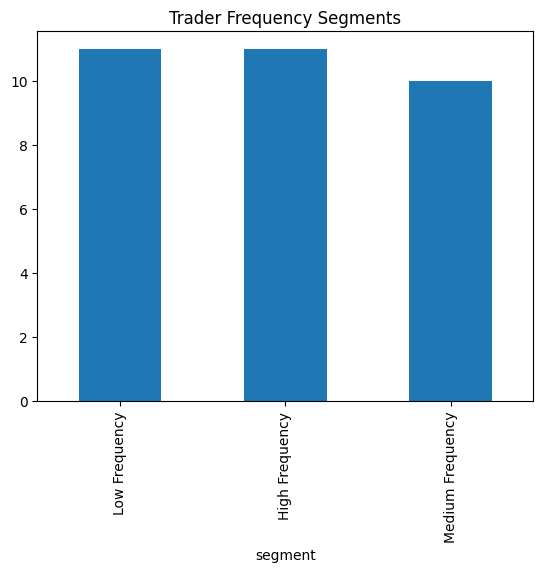

In [99]:
trader_freq["segment"].value_counts().plot(kind="bar")
plt.title("Trader Frequency Segments")
plt.show()

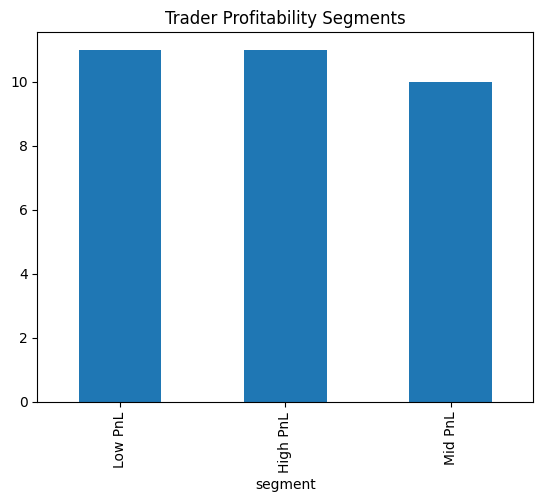

In [100]:
trader_pnl["segment"].value_counts().plot(kind="bar")
plt.title("Trader Profitability Segments")
plt.show()

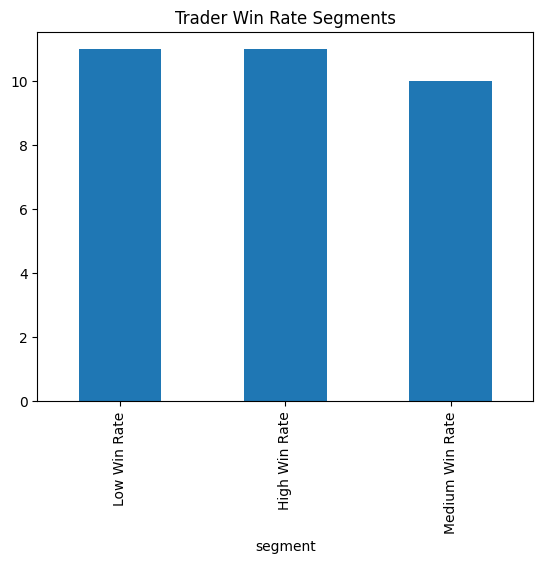

In [101]:
wins["segment"].value_counts().plot(kind="bar")
plt.title("Trader Win Rate Segments")
plt.show()

# Part C — Actionable Output

Based on trader behavior and performance under different sentiment conditions, the following strategy rules are recommended.

## Strategy Idea 1: Defensive Positioning During Greed Days

Observed data showed:

- Greed periods had slightly higher average profitability
- However, win rate was lower than Fear periods
- Traders also showed stronger short bias during Greed sentiment

### Rule of Thumb:

During Greed days:

- Reduce leverage exposure
- Prefer smaller position sizes
- Use tighter stop-loss controls
- Prioritize short-term tactical trades rather than oversized conviction trades

### Rationale:

Although profits can be strong during Greed periods, lower win rates suggest increased volatility and overconfidence risk.

## Strategy Idea 2: Higher Conviction Long Trades During Fear Days

Observed data showed:

- Fear days had higher win rates
- Traders favored long positions
- Average trade size was larger during Fear sentiment

### Rule of Thumb:

During Fear days:

- Focus on selective long setups
- Allow moderate position sizing for high-confidence entries
- Avoid excessive overtrading
- Use medium holding periods to capture rebounds

### Rationale:

Fear environments may create discounted entry opportunities, where disciplined traders can achieve stronger consistency.

# Final Strategic Conclusion

Market sentiment affects both profitability and trader behavior.

- Greed sentiment may reward tactical, risk-controlled trading.
- Fear sentiment may reward selective contrarian long exposure.

Adapting leverage, direction bias, and trade frequency to sentiment regimes can improve decision-making.

# Bonus Analysis — Trader Archetype Clustering

Using KMeans clustering, traders were grouped into 3 behavioral archetypes using:

- Trade Frequency
- Average Position Size
- Total Profitability
- Win Rate

## Cluster Profiles

### Cluster 0 — Elite High-Volume Traders

- Highest trading frequency
- Largest average trade sizes
- Highest realized profits
- Strong win rate

These traders appear to scale profits through activity and capital deployment.

### Cluster 1 — Average Opportunistic Traders

- Moderate activity
- Moderate sizing
- Lowest profitability
- Lowest win rate

This group may trade frequently without strong edge or discipline.

### Cluster 2 — Efficient Precision Traders

- Lower activity
- Smaller trade sizes
- Highest win rate
- Strong profitability

These traders appear highly selective and efficient.

In [107]:
cluster_df = merged_dataframe.groupby("Account").agg(
    trade_count=("Account","size"),
    avg_leverage=("leverage","mean"),
    avg_size=("Size USD","mean"),
    total_pnl=("Closed PnL","sum"),
).reset_index()

# win rate
wins = comparison_pnl.groupby("Account")["win"].mean().reset_index()
cluster_df = cluster_df.merge(wins,on="Account",how="left")

features = cluster_df[["trade_count","avg_leverage","avg_size","total_pnl","win"]]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(X)

cluster_df.groupby("cluster").mean(numeric_only=True).round(2)

,trade_count,avg_leverage,avg_size,total_pnl,win
cluster,,,,,
0,18432.60,-125881.79,11889.75,1272055.87,0.84
1,4452.54,108890.76,5521.96,92779.50,0.75
2,4369.86,7949853.40,4358.54,195039.01,0.96


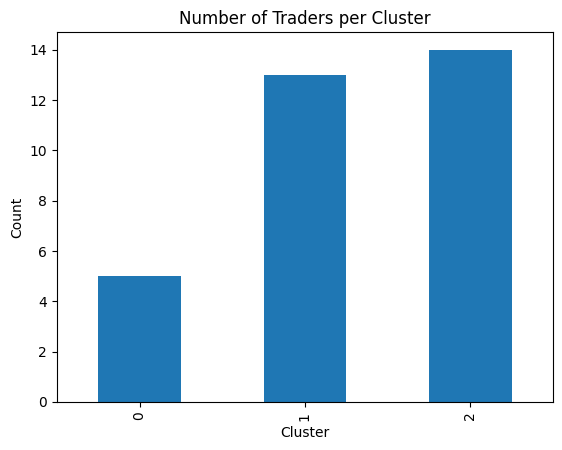

In [108]:
cluster_df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Traders per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## Clustering Insight

Two successful trader styles emerged:

1. High-volume scaling strategy (Cluster 0)
2. Selective high-accuracy strategy (Cluster 2)

This suggests traders can succeed either through scale or precision.

Note: Leverage values contained outliers, so cluster interpretation focused primarily on trade frequency, profitability, size, and win rate.